In [15]:
import pandas as pd
import re
import pickle
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Load data
df = pd.read_csv("IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [7]:
# Clean text
def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)      # remove HTML tags
    text = re.sub(r'[^a-z\s]', '', text)  # remove punctuation
    return text

In [8]:
df['review'] = df['review'].apply(clean_text)

In [10]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    df['review'], df['sentiment'], test_size=0.2, random_state=42
)

In [11]:
# Vectorize
vectorizer = TfidfVectorizer(max_features=10000, stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [12]:
# Train both models and compare
lr_model = LogisticRegression(max_iter=200)
lr_model.fit(X_train_vec, y_train)
lr_acc = accuracy_score(y_test, lr_model.predict(X_test_vec))

In [13]:
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)
nb_acc = accuracy_score(y_test, nb_model.predict(X_test_vec))


In [14]:
print(f"Logistic Regression Accuracy: {lr_acc:.4f}")
print(f"Naive Bayes Accuracy:         {nb_acc:.4f}")


Logistic Regression Accuracy: 0.8875
Naive Bayes Accuracy:         0.8555


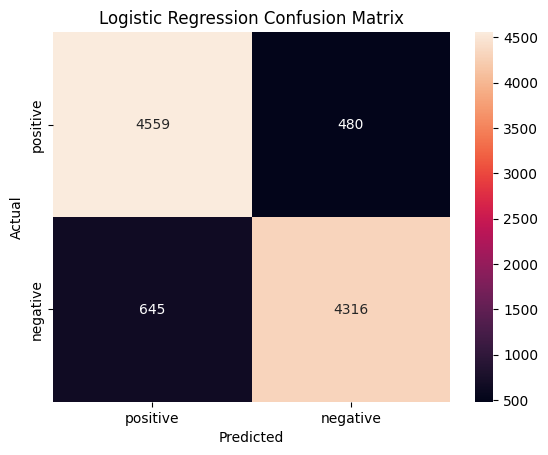

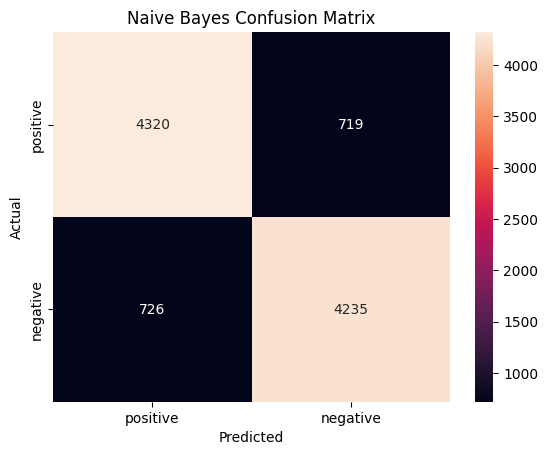

In [16]:
for model_name, y_pred in [("Logistic Regression", lr_model.predict(X_test_vec)),
                           ("Naive Bayes", nb_model.predict(X_test_vec))]:
    cm = confusion_matrix(y_test, y_pred, labels=['positive','negative'])
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=['positive','negative'], yticklabels=['positive','negative'])
    plt.title(f"{model_name} Confusion Matrix")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

In [17]:
from sklearn.metrics import classification_report

print("Logistic Regression Report:\n", classification_report(y_test, lr_model.predict(X_test_vec)))
print("Naive Bayes Report:\n", classification_report(y_test, nb_model.predict(X_test_vec)))

Logistic Regression Report:
               precision    recall  f1-score   support

    negative       0.90      0.87      0.88      4961
    positive       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

Naive Bayes Report:
               precision    recall  f1-score   support

    negative       0.85      0.85      0.85      4961
    positive       0.86      0.86      0.86      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



In [18]:
import numpy as np

sample_idx = np.random.choice(len(X_test_vec.toarray()), 5, replace=False)
for idx in sample_idx:
    print(f"Review: {X_test.iloc[idx][:100]}...")
    print("LR Prediction:", lr_model.predict(X_test_vec[idx])[0],
          "Probabilities:", lr_model.predict_proba(X_test_vec[idx])[0])
    print("NB Prediction:", nb_model.predict(X_test_vec[idx])[0],
          "Probabilities:", nb_model.predict_proba(X_test_vec[idx])[0])
    print("Actual:", y_test.iloc[idx])
    print("------")

Review: how can barry levinson possibly assemble whitehot comedy talents ben stiller and jack black the gorg...
LR Prediction: negative Probabilities: [0.54503858 0.45496142]
NB Prediction: negative Probabilities: [0.63566476 0.36433524]
Actual: negative
------
Review: i dont really know why but i watched this with quite a sense of anticipation unfortunatly it was mis...
LR Prediction: negative Probabilities: [0.9642891 0.0357109]
NB Prediction: negative Probabilities: [0.87120413 0.12879587]
Actual: negative
------
Review: i saw this movie on tv and loved it i am a real disaster film fan and this one was great the cast wa...
LR Prediction: positive Probabilities: [0.09963749 0.90036251]
NB Prediction: positive Probabilities: [0.43274783 0.56725217]
Actual: positive
------
Review: jaded offers a premise with potential as it looks at the rape of a woman by two other women and ask ...
LR Prediction: negative Probabilities: [0.97849545 0.02150455]
NB Prediction: negative Probabilities: [0

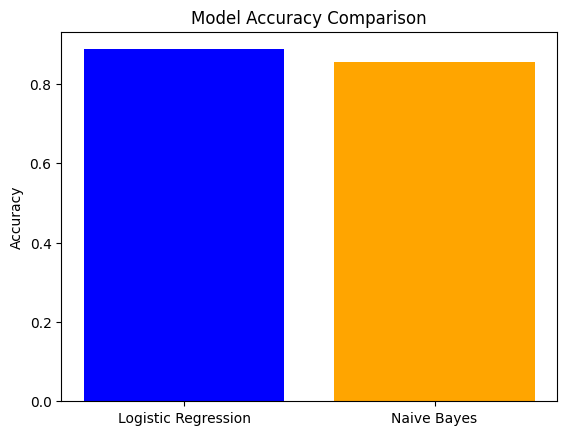

In [19]:
plt.bar(['Logistic Regression','Naive Bayes'], [lr_acc, nb_acc], color=['blue','orange'])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [20]:
# Save the better model (spoiler: LR wins here)
pickle.dump(lr_model, open("model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))
print("Model saved!")

Model saved!
